# Tree-Based Models

Comparing Decision Tree, Random Forest, and XGBoost against the logistic regression baseline (AUC ~0.63) for predicting NBA shot make/miss. Tree models can capture nonlinear relationships and feature interactions that logistic regression cannot, making them a natural next step after the baseline.

In [7]:
import os
from pathlib import Path

# ensure working directory is the project root, not the notebooks/ folder
if Path.cwd().name == "notebooks":
    os.chdir("..")

print("Working directory:", Path.cwd())

Working directory: c:\Users\micha\Downloads\CS158\Shot-Value-Machine-Learning


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, roc_auc_score, log_loss,
                             confusion_matrix, ConfusionMatrixDisplay,
                             roc_curve, auc)
import xgboost as xgb

df_clean = pd.read_csv("data/processed/shot_logs_cleaned.csv")

In [ ]:
# expanded feature set that includes shot context, engineered interactions, and shot type flags
features = [
    "shot_dist",           # distance from basket
    "close_def_dist",      # nearest defender distance
    "shot_clock",          # time remaining on shot clock
    "dribbles",            # dribbles taken before shot
    "touch_time",          # seconds holding ball before shot
    "game_clock_pct",      # normalized game time elapsed
    "shot_clock_pct",      # normalized shot clock urgency
    "catch_and_shoot",     # flag: catch-and-shoot attempt
    "dribble_pull_up",     # flag: dribble pull-up attempt
    "def_dist_x_shot_dist",# interaction: defense × distance
    "shot_dist_squared",   # nonlinear distance effect
    "pts_type",            # 2 or 3 point attempt
    "location",            # home or away
    "period"               # quarter of the game
]

X = df_clean[features].copy()
# encode location as binary: H=1 (home), A=0 (away) (done for numeric input)
X["location"] = (X["location"] == "H").astype(int)
y = df_clean["made"]

# 80/20 split: no scaling done, tree models are scale-invariant
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape: ", X_test.shape)

X_train shape: (102205, 14)
X_test shape:  (25552, 14)


In [10]:
# --- Decision Tree ---
# shallow tree (max_depth=5) with leaf size constraint to avoid overfitting
dt = DecisionTreeClassifier(max_depth=5, min_samples_leaf=100, random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)
y_prob_dt = dt.predict_proba(X_test)[:, 1]

print("=== Decision Tree ===")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("ROC AUC: ", roc_auc_score(y_test, y_prob_dt))
print("Log Loss:", log_loss(y_test, y_prob_dt))

=== Decision Tree ===
Accuracy: 0.6162726988102692
ROC AUC:  0.629276182187982
Log Loss: 0.6532018407635753


In [11]:
# --- Random Forest ---
# ensemble of 200 trees with moderate depth to balance bias-variance
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=50,
    n_jobs=-1,
    random_state=42
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

print("=== Random Forest ===")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("ROC AUC: ", roc_auc_score(y_test, y_prob_rf))
print("Log Loss:", log_loss(y_test, y_prob_rf))

=== Random Forest ===
Accuracy: 0.6200297432686287
ROC AUC:  0.639737816672907
Log Loss: 0.6486520041485213


In [12]:
# --- XGBoost ---
# gradient boosted trees with conservative learning rate and subsampling for regularization
xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=50
)

y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

print("\n=== XGBoost ===")
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("ROC AUC: ", roc_auc_score(y_test, y_prob_xgb))
print("Log Loss:", log_loss(y_test, y_prob_xgb))

[0]	validation_0-logloss:0.68660
[50]	validation_0-logloss:0.65028
[100]	validation_0-logloss:0.64817
[150]	validation_0-logloss:0.64766
[200]	validation_0-logloss:0.64760
[250]	validation_0-logloss:0.64742
[299]	validation_0-logloss:0.64744

=== XGBoost ===
Accuracy: 0.6191687539135879
ROC AUC:  0.641601919753252
Log Loss: 0.647440330771423


In [14]:
# compare all models side-by-side, including the logistic regression baseline from notebook 04
results = pd.DataFrame([
    {"Model": "Logistic Regression", "Accuracy": 0.609, "ROC AUC": 0.630, "Log Loss": 0.657},
    {"Model": "Decision Tree",       "Accuracy": accuracy_score(y_test, y_pred_dt),
                                     "ROC AUC": roc_auc_score(y_test, y_prob_dt),
                                     "Log Loss": log_loss(y_test, y_prob_dt)},
    {"Model": "Random Forest",       "Accuracy": accuracy_score(y_test, y_pred_rf),
                                     "ROC AUC": roc_auc_score(y_test, y_prob_rf),
                                     "Log Loss": log_loss(y_test, y_prob_rf)},
    {"Model": "XGBoost",             "Accuracy": accuracy_score(y_test, y_pred_xgb),
                                     "ROC AUC": roc_auc_score(y_test, y_prob_xgb),
                                     "Log Loss": log_loss(y_test, y_prob_xgb)},
])

results = results.set_index("Model").round(4)
results

,Accuracy,ROC AUC,Log Loss
Model,,,
Logistic Regression,0.6090,0.6300,0.6570
Decision Tree,0.6163,0.6293,0.6532
Random Forest,0.6200,0.6397,0.6487
XGBoost,0.6192,0.6416,0.6474


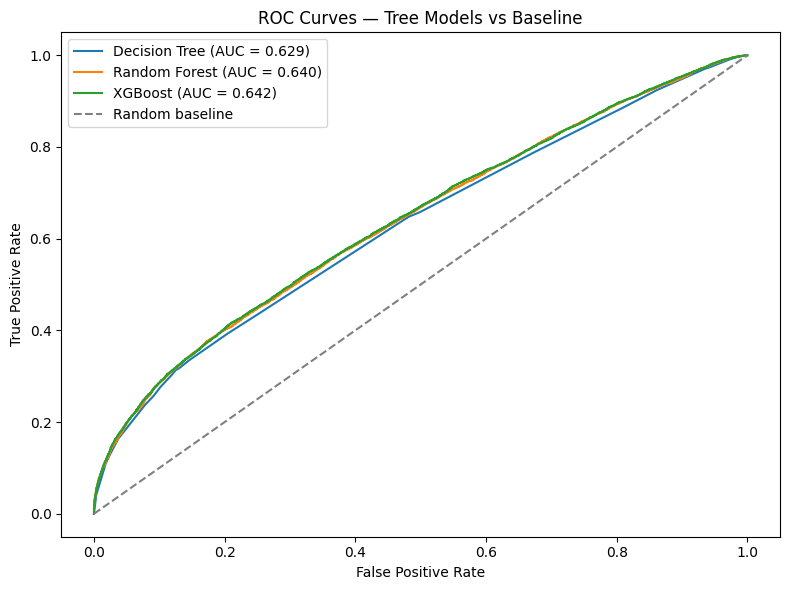

In [15]:
# overlay ROC curves for all three tree models on a single plot
fig, ax = plt.subplots(figsize=(8, 6))

for name, y_prob in [("Decision Tree", y_prob_dt),
                     ("Random Forest", y_prob_rf),
                     ("XGBoost",       y_prob_xgb)]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})")

# dashed diagonal represents a random classifier (baseline)
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random baseline")

ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves — Tree Models vs Baseline")
ax.legend()
plt.tight_layout()
plt.show()

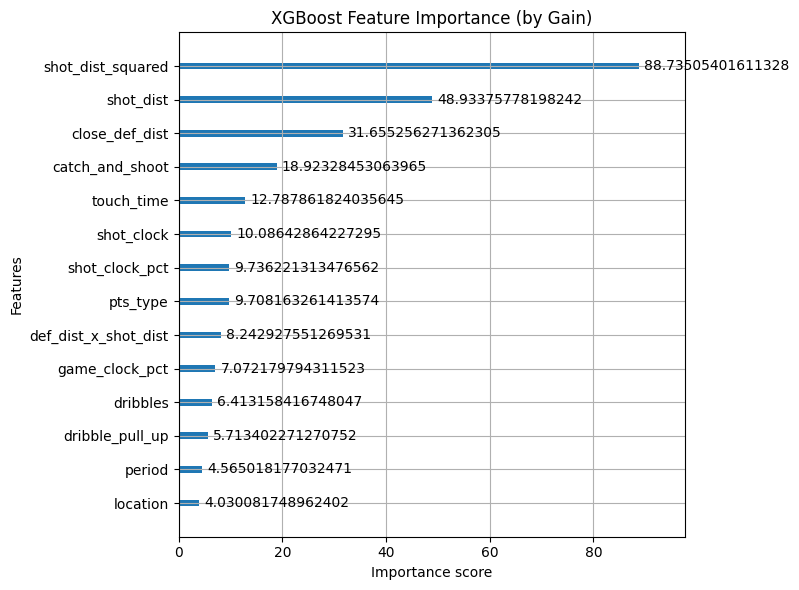

In [16]:
# which features drive XGBoost predictions the most, measured by total information gain
fig, ax = plt.subplots(figsize=(8, 6))
xgb.plot_importance(xgb_model, ax=ax, max_num_features=14, importance_type="gain")
ax.set_title("XGBoost Feature Importance (by Gain)")
plt.tight_layout()
plt.show()

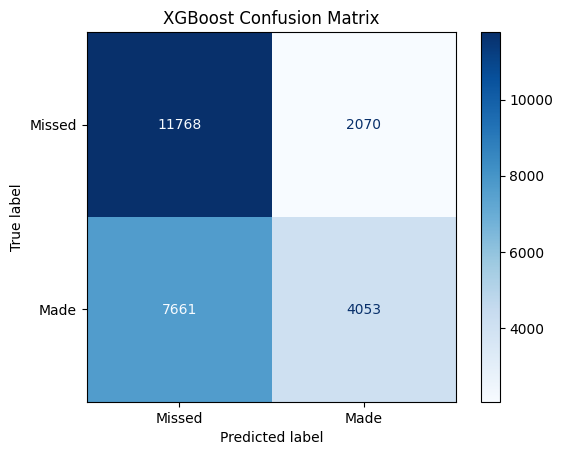

In [17]:
# visualize XGBoost classification results at the default 0.5 threshold
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_xgb, display_labels=["Missed", "Made"])
disp.plot(cmap="Blues")
plt.title("XGBoost Confusion Matrix")
plt.show()

## Summary

All three tree models improved on the logistic regression baseline, but the gains were modest. XGBoost was the strongest performer with an AUC of 0.642 and the lowest log loss (0.647), suggesting it produces the best-calibrated probability estimates which could be understood as meaningful for a shot quality model where the actual predicted probability matters and not just the ranking. The XGBoost validation log loss curve also plateaued around iteration 200, indicating the model converged cleanly without significant overfitting.

Random Forest was close behind (AUC 0.640), confirming that ensemble methods capture structure the baseline missed. The single Decision Tree was the weakest of the three and slightly underperformed logistic regression on AUC (0.629 vs 0.630), showing that a shallow tree alone adds little over a linear model on this data.

The narrow spread across all models (AUC range: 0.629–0.642) points to a ceiling imposed by the available features. Shot distance, defender proximity, and shot clock explain only so much; the remaining variance is largely shooter skill, which is not captured in this dataset.

**Next steps:**
- Add shooter-level features (e.g., player career FG% at a given distance range) to reduce unexplained variance
- Cross-validate all models to confirm AUC estimates are stable across splits
- Hyperparameter tune XGBoost (depth, learning rate, subsampling) to probe whether more performance is available within this feature set